## Exercise Project 2
_Using `LogisticRegression`_

<br>
<br>




### Dataset: [Loan Classification Approval](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data)

|Parameter|Description|
|---|---|
|Shape|`45k rows, 23 columns`|
|Target Variable|`loan_status`|
|Method:|`LogisticRegression`
|Extra Tools:|`None`|

<br>

<i>
<strong style='color:red ; background-color:black;'> 

#### Disclosure: 

I used AI to convert the table from the kaggle dataset webpage into a markdown table.

#### Prompt:

 /paste Kaggle column descriptions/. 
 
 Could you put this into a markdown table for me? 
</strong>
</i>
#### Column Descriptions:


| Column | Description |
|---|---|
| person_age | Age of the person |
| person_gender | Gender of the person |
| person_education | Highest education level |
| person_income | Annual income |
| person_emp_exp | Years of employment experience |
| person_home_ownership | Home ownership status (e.g., rent, own, mortgage) |
| loan_amnt | Loan amount requested |
| loan_intent | Purpose of the loan |
| loan_int_rate | Loan interest rate |
| loan_percent_income | Loan amount as a percentage of annual income |
| cb_person_cred_hist_length | Length of credit history in years |
| credit_score | Credit score of the person |
| previous_loan_defaults_on_file | Indicator of previous loan defaults |
| loan_status | Loan approval status: 1 = approved; 0 = rejected |

#### Summary:

<i>
Add Text Here.
</i>

#### Results:

<i>
Add Text Here.
</i>

<br>
<br>


---

## Code:

#### Imports and Data Loading

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from skfeature.function.similarity_based import fisher_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# Loading dataframe
df = pd.read_csv("datasets/loan_data.csv")
df.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Checking the shape

In [3]:
# Checking the shape
df.shape

# 45,000 rows
# 23 columns

(45000, 14)

#### Handling Duplicates

In [4]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

#### Handling Missing Values

In [5]:
# Checking NaN values
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

#### Checking For Isolated Categorical Cases

`person_education`

In [6]:
# Checking for isolated cases.

# Person Education value counts.
df["person_education"].value_counts()

# The lowest is 621, it's fine.

person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

`person_home_ownership`

In [7]:
df['person_home_ownership'].value_counts()

# Yep, seems fine. 

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

`loan_intent`

In [8]:
df['loan_intent'].value_counts()

# Healthy distribution.

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

`person_gender`

In [9]:
df["person_gender"].value_counts()

# OK as well.

person_gender
male      24841
female    20159
Name: count, dtype: int64

#### Transforming Columns to Numbers

##### Categorical

In [10]:
# We'll be turning all these into binary numeric column.
categorical_columns = ["person_education", "person_home_ownership", "loan_intent"]

# OneHotEncoder to transform each categorical to separate, binary numeric.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)
    
# Dropping one column from each categorical variable.
df = df.drop([
    "loan_intent_VENTURE",
    "person_home_ownership_OTHER",
    "person_education_High School",
], axis=1)

#### Binary Columns

In [11]:
from sklearn.preprocessing import LabelEncoder

# If you have a binary datatype column, this will convert it into numbers.
variables = ['person_gender', 'previous_loan_defaults_on_file']

encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

# For `previous_loan_defaults_on_file` : No=0, Yes=1
# For `person_gender` : Female=0, Male=1
 

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1| Data Cleaning |
|2|<bold style="background:yellow;color:black;"> Transformation </bold>|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Checking distributions

##### Target Variable

In [12]:
df['loan_status'].value_counts()

# Quite a bit more rejected than approved. I wonder if this will affect the outcome?

loan_status
0    35000
1    10000
Name: count, dtype: int64

##### Features

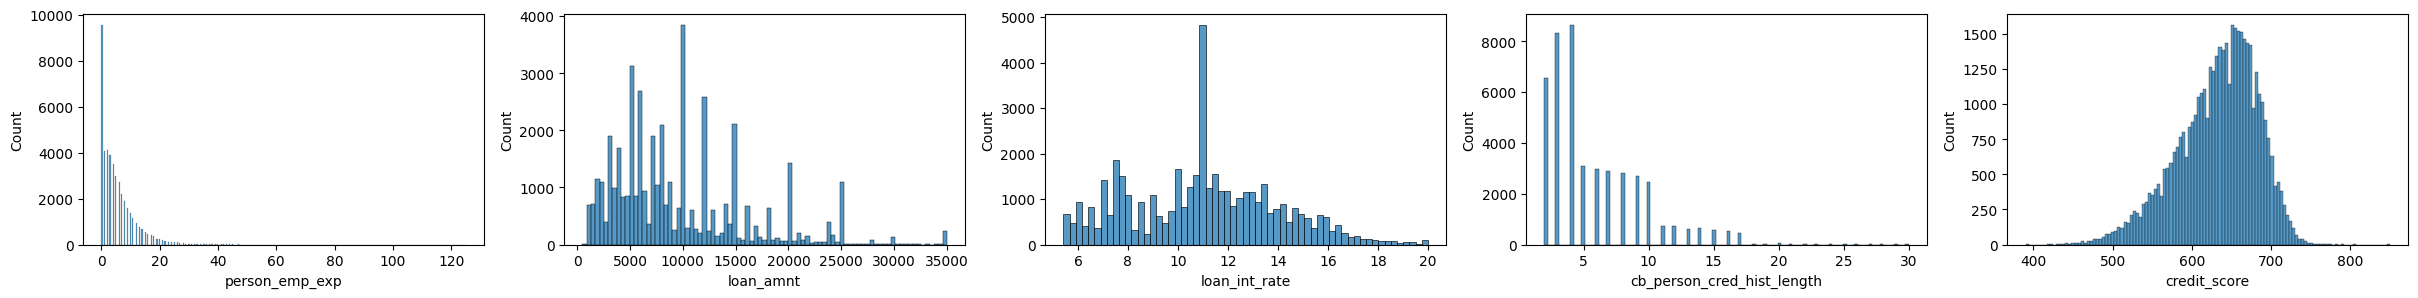

In [13]:
# Makes a loop that shows the distributions for every possible feature.

# Create a dataframe without the target variable.
features = df[["person_emp_exp","loan_amnt",'loan_int_rate', 'cb_person_cred_hist_length','credit_score']]

# Get the amount of columns. Used to say how many plots we need
len_columns = len(features.columns)

# Create a canvas, this will be where the plots go into.
fig, axes = plt.subplots(1, len_columns, figsize=(30, 3))

# For each plot in the index...
for index, feature in enumerate(features.columns): 
    # Get the place where the plot goes into...
    plot_num = index
    # Make a histplot, tell it where the plot goes, and which feature is needed.
    sns.histplot(features, x=feature, ax=axes[plot_num])
    
    

<i>

`person_emp_exp`
`cb_preson_cred_hist_length`

These features both have a beta distribution. I'll check later how certain transformations affect the prediction outcomes.



#### VIF Test

<i> Let's look for multicollinearity using the VIF test.

In [14]:
# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

X = df.drop("loan_status", axis=1)

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 


# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, confusing the logistic regression

vif_data.sort_values(by="VIF", ascending=False)

,feature,VIF
0,person_age,242.122718
8,credit_score,137.964500
16,person_home_ownership_RENT,102.399366
14,person_home_ownership_MORTGAGE,80.740239
3,person_emp_exp,16.303599
5,loan_int_rate,15.351924
15,person_home_ownership_OWN,13.731723
7,cb_person_cred_hist_length,12.542746
6,loan_percent_income,7.899644
4,loan_amnt,7.291280


<i>

We have some really high VIF-values. We'll keep that in mind as we select features.

#### Selecting Features

##### Correlation bar chart.

C:\Users\OWNER\AppData\Local\Temp\ipykernel_1412\3215803179.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(loan_status_corr,y="column", x="correlation_value", ci=None)


<Axes: xlabel='correlation_value', ylabel='column'>

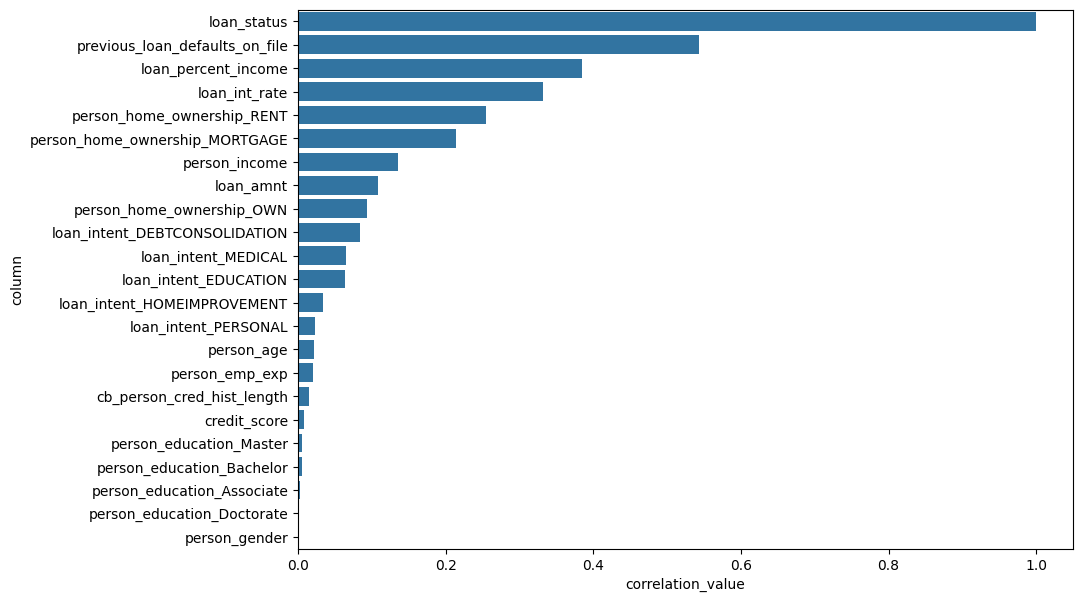

In [15]:
# Make a pearson correlation dataframe, and filter corrlations to only be related
# to the target variable.
corr = df.corr(method='pearson', numeric_only=True).sort_values(by="loan_status")
loan_status_corr = corr['loan_status'].reset_index()

# Rename the columns
loan_status_corr = loan_status_corr.rename(columns={
    "index":"column",
    "loan_status": "correlation_value"
})

# I'm just interested in the strength of the relationship.
# Turn all negative correlations into positive ones.
loan_status_corr["correlation_value"] = abs(loan_status_corr["correlation_value"])

# Sort the values one more time. 
loan_status_corr = loan_status_corr.sort_values("correlation_value", ascending = False)

# Make a bar chart to visualize the feature effectiveness using pearson.
plt.figure(figsize=(10, 7))
sns.barplot(loan_status_corr,y="column", x="correlation_value", ci=None)

<i>

Some interesting notes:

The bank doesn't discriminate by gender it seems. The amount of education also really doesn't matter. Surprisingly, credit score ALSO does not matter there much. This is suspicious actually, since credit_score in The United States is one of the most significant factors to being approved/denied for loans. Maybe it's not a US dataset, for once.

The loan interest rate seems to play a very big role with the decision. This is also a little strange, because most banks I'm familiar with approves loans and the bank sets the interest rate based on the offer. Very confusing, this might be synthetic data.

#### Fisher Score

In [16]:
from skfeature.function.similarity_based import fisher_score

# -- FISHER SCORE -- 
# Useful particular for categorical target variables (classification).

# Set a sample (if it's too big, you'll be there all day)
sample = df.sample(5000)

# Split the features
X = sample.drop('loan_status', axis=1)
y = sample['loan_status']

# get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)
# # create a pandas DataFrame for easier interpretation
feat_importances = pd.Series(ranks, X.columns).sort_values()

# The lower the rank, the better.
feat_importances


person_home_ownership_MORTGAGE     0
credit_score                       1
person_home_ownership_OWN          2
person_education_Associate         3
previous_loan_defaults_on_file     4
person_emp_exp                     5
loan_percent_income                6
loan_amnt                          7
person_home_ownership_RENT         8
loan_intent_EDUCATION              9
loan_intent_PERSONAL              10
loan_intent_MEDICAL               11
person_age                        12
loan_intent_DEBTCONSOLIDATION     13
person_education_Doctorate        14
person_gender                     15
person_income                     16
loan_int_rate                     17
person_education_Master           18
cb_person_cred_hist_length        19
loan_intent_HOMEIMPROVEMENT       20
person_education_Bachelor         21
dtype: int64

#### SelectKBest

<Axes: xlabel='Score', ylabel='Features'>

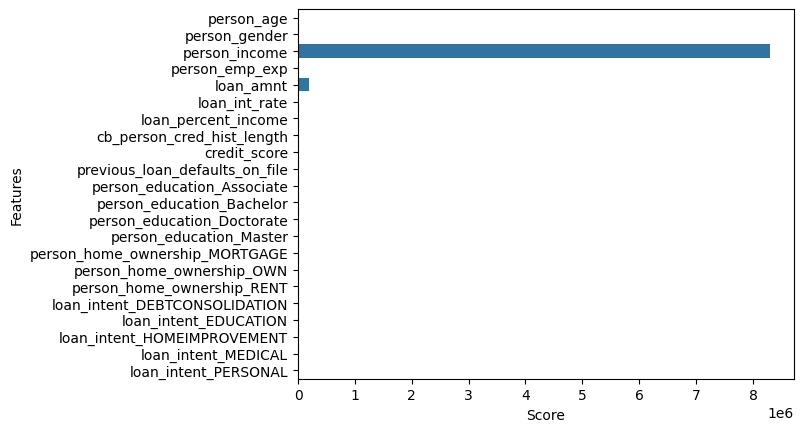

In [17]:
# -- SELECTKBEST --
# Basically, rank the features by statistical significance.
# Works with regression or classification

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# convert all continuous variables to integer
X_cat = X.astype(int) 

# Use chi squared to help provide provide statistical
# significance metrix.
chi_2_features = SelectKBest(chi2, k=10)

# fit our data to the SelectKBest
best_features = chi_2_features.fit(X_cat, y)

# Turn the features and columns into dataframes.
df_features = pd.DataFrame(best_features.scores_)
df_columns = pd.DataFrame(X.columns)

# Combine them and sort the values by 'Score'
f_scores = pd.concat([df_columns,df_features],axis=1)
f_scores.columns = ['Features','Score']
f_scores.sort_values(by='Score',ascending=False)

# Plot the result.
sns.barplot(f_scores, y="Features", x="Score")

<i>

Makes complete sense. The loan amount and person's income are likely very huge factors for loan approvals

#### Creating a Feature List

In [18]:
# Creating a list of features. These will be the ones that we'll be training
# the model on.
features_list = list(X.columns)

# Remove some features from the list.
features_list.remove("person_gender")                    # Not significant
features_list.remove("person_education_Doctorate")       # Not significant
features_list.remove("person_education_Bachelor")        # Not significant
features_list.remove("person_education_Associate")       # Not significant
features_list.remove("person_education_Master")          # Not significant
features_list.remove("credit_score")                     # VIF score too high
features_list.remove("person_home_ownership_RENT")       # VIF score too high
features_list

['person_age',
 'person_income',
 'person_emp_exp',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'previous_loan_defaults_on_file',
 'person_home_ownership_MORTGAGE',
 'person_home_ownership_OWN',
 'loan_intent_DEBTCONSOLIDATION',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL']

---

### ML Training & Metrics

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| <bold style="background:yellow;color:black;">ML Training & Metrics </bold>|
|4| Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Training the model

In [19]:
# Defining dependent, independent variables.
X = df[features_list]
y = df['loan_status']

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=101)

# Abbreviate Standard Scaler.
sc = StandardScaler()

# FIT the scaler to X-training data
# transform to X-test data.
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# create the model and train it with the data
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Predict X_test, accuracy metrics

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     10471
           1       0.76      0.74      0.75      3029

    accuracy                           0.89     13500
   macro avg       0.85      0.84      0.84     13500
weighted avg       0.89      0.89      0.89     13500


Model overall accuracy: 89.08%


<Axes: >

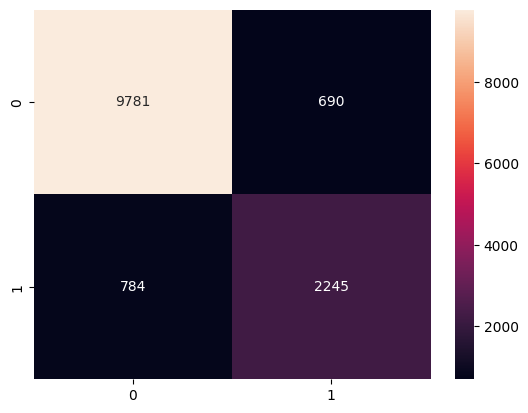

In [20]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

In [21]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Yippie!

0.9516572978257262

---

#### Creating a Tester Row

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6| Advanced Tasks|

In [22]:
tester_row = {
    'person_age': 20,
    'person_income': 30000,
    'person_emp_exp': 4,
    'loan_amnt': 6000,
    'loan_int_rate': 9,
    'loan_percent_income': 0.88,
    'cb_person_cred_hist_length': 2.0,
    'previous_loan_defaults_on_file': 0,
    'person_home_ownership_MORTGAGE': 0,
    'person_home_ownership_OWN': 1,
    'loan_intent_DEBTCONSOLIDATION': 1,
    'loan_intent_EDUCATION': 0,
    'loan_intent_HOMEIMPROVEMENT': 0,
    'loan_intent_MEDICAL': 0,
    'loan_intent_PERSONAL': 0
}

tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]

if result == 0:
    result = "Loan denied"
else:
    result = "Loan Approved"

print(result)

Loan denied


c:\Users\OWNER\Intro_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---

### Personal Analysis

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis</bold>|
|6| Advanced Tasks|

---

### Advanced Tasks

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis |
|6| <bold style="background:yellow;color:black;">Advanced Tasks</bold> |